# Atividade IV: Segmentação, Morfologia e Extração de Características
*Por* **Fabricia Cristina Marques Jung**

Visão Computacional, Residência em TIC43. Unidade 3, Capítulo 1.

## 1. Introdução

A proposta aqui é montar um pipeline de análise de imagem do início ao fim, sobre uma cena com
vários objetos, e ir interpretando o que sai de cada etapa. As etapas são:

1. Aquisição da imagem
2. Segmentação para separar os objetos do fundo
3. Operações morfológicas para limpar a máscara
4. Identificação dos objetos por componentes conectados
5. Extração de características de cada objeto
6. Análise dos resultados

Escolhi a imagem `coins`, da biblioteca `skimage.data`: uma foto com 24 moedas sobre fundo escuro.
Ela serve bem porque tem vários objetos parecidos, em tamanhos e brilhos diferentes, e com algumas
moedas se encostando. Esse contato deixa a segmentação e a contagem mais difíceis (e mais
realistas), e ainda evita depender de download externo.

## 2. Aquisição da imagem

A imagem vem direto da `skimage.data`, então dá para rodar o notebook no Colab sem nenhum arquivo
externo. Abaixo mostro a original e algumas informações básicas (dimensões, tipo e faixa de
intensidade).

Dimensões: (303, 384)
Tipo: uint8
Intensidade: min = 1 | max = 252


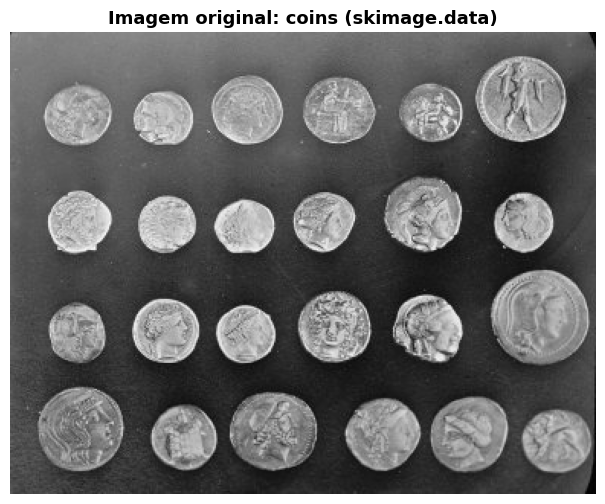

In [1]:
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from skimage import data, filters, morphology, measure, segmentation, feature, color
from scipy import ndimage as ndi

plt.rcParams['image.cmap'] = 'gray'

img = data.coins()

print('Dimensões:', img.shape)
print('Tipo:', img.dtype)
print('Intensidade: min =', int(img.min()), '| max =', int(img.max()))

plt.figure(figsize=(8, 6))
plt.imshow(img)
plt.title('Imagem original: coins (skimage.data)', fontsize=13, fontweight='bold')
plt.axis('off')
plt.show()

**Descrição do conteúdo.** São 303 x 384 pixels em tons de cinza (8 bits, de 0 a 255), com 24
moedas distribuídas em quatro fileiras sobre fundo escuro. As moedas têm diâmetros e brilhos
diferentes, e algumas se tocam, principalmente na fileira de cima. O fundo também não é totalmente
uniforme: tem um leve gradiente de luz, mais claro no meio e mais escuro nas bordas. Esse detalhe
acaba atrapalhando na hora de segmentar.

## 3. Segmentação

O objetivo desta etapa é separar as moedas do fundo. Optei pela **limiarização global de Otsu**.
O motivo é que o histograma da imagem é mais ou menos bimodal, com um grupo de pixels escuros (o
fundo) e outro de pixels claros (as moedas), e o Otsu acha sozinho o limiar que melhor divide os
dois, sem precisar ficar testando valor na mão. Antes de limiarizar, passo uma suavização gaussiana
leve para reduzir o ruído e evitar buracos na máscara.

Limiar de Otsu: 103.2
Fração da imagem classificada como objeto: 42.3%


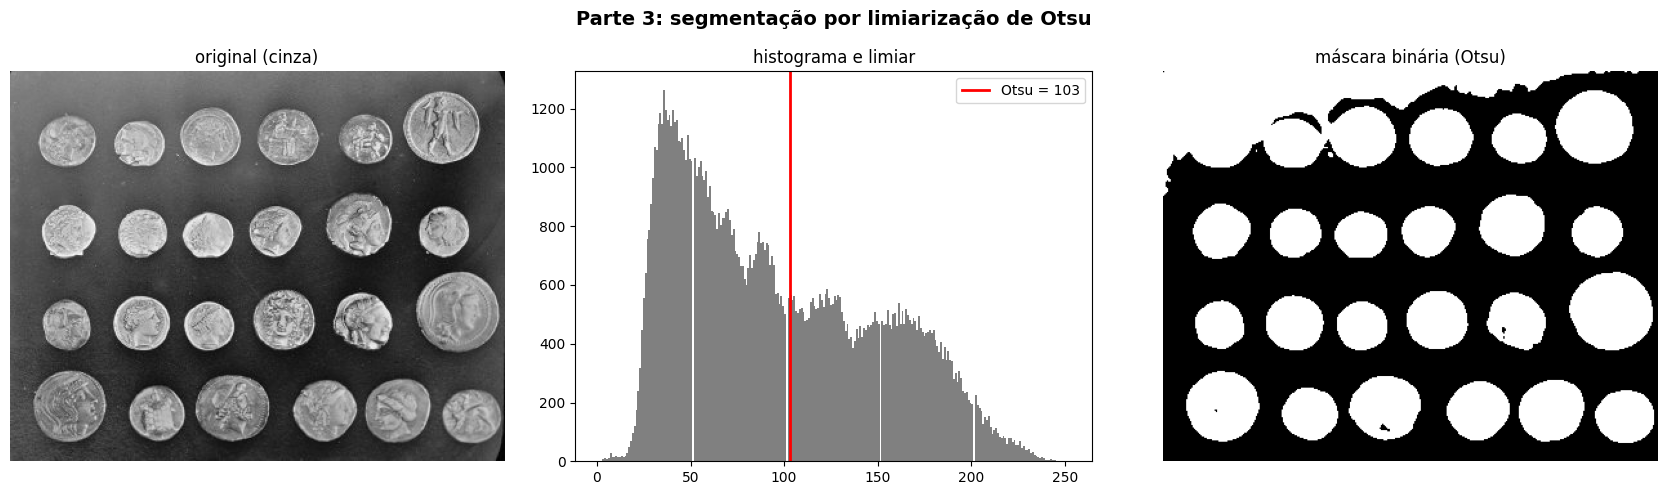

In [2]:
suave = filters.gaussian(img, sigma=1.5, preserve_range=True)
limiar = filters.threshold_otsu(suave)
mascara = suave > limiar

print(f'Limiar de Otsu: {limiar:.1f}')
print(f'Fração da imagem classificada como objeto: {mascara.mean() * 100:.1f}%')

fig, axes = plt.subplots(1, 3, figsize=(17, 5))
axes[0].imshow(img)
axes[0].set_title('original (cinza)')
axes[1].hist(img.ravel(), bins=256, color='gray')
axes[1].axvline(limiar, color='red', linewidth=2, label=f'Otsu = {limiar:.0f}')
axes[1].set_title('histograma e limiar')
axes[1].legend()
axes[2].imshow(mascara)
axes[2].set_title('máscara binária (Otsu)')
for ax in (axes[0], axes[2]):
    ax.axis('off')
plt.suptitle('Parte 3: segmentação por limiarização de Otsu', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

**Por que esse método.** O Otsu é rápido, automático e funciona bem quando objeto e fundo têm
brilhos bem diferentes, que é o caso das moedas claras sobre fundo escuro.

**Dificuldades encontradas.** Apareceram duas. A primeira é a iluminação não uniforme: como o
limiar vale para a imagem toda, o fundo continua bem separado, mas a borda de algumas moedas, onde
o brilho cai, fica fraca e a máscara sai meio roída ali. A segunda é que moedas que se tocam saem
grudadas, viram um borrão só em vez de objetos separados.

**A segmentação foi satisfatória?** Em parte. Ela separa muito bem as moedas do fundo, que é o que
a limiarização promete, mas não separa moedas vizinhas nem fecha por completo o miolo de cada peça.
Esses dois problemas eu trato nas etapas seguintes, com morfologia e com o watershed.

## 4. Operações morfológicas

A máscara do Otsu vem com defeitos pequenos: ruído solto no fundo e buracos dentro das moedas. As
operações morfológicas resolvem isso com um elemento estruturante (usei um disco de raio 3). Mostro
as quatro operações básicas e depois monto a máscara final que segue no pipeline:

* **Erosão**: encolhe as regiões claras e tira pontos pequenos, mas também afina as moedas.
* **Dilatação**: o contrário, engorda as regiões e tapa pequenas falhas, com o risco de unir vizinhas.
* **Abertura** (erosão e depois dilatação): tira o ruído solto sem encolher o objeto.
* **Fechamento** (dilatação e depois erosão): fecha buracos e falhas internas.

Para a máscara final juntei a abertura, que limpa o fundo, com o preenchimento de buracos, que fecha
o miolo das moedas. Não usei o fechamento no resultado final porque, nesta imagem, ele acaba colando
moedas que estão só encostadas.

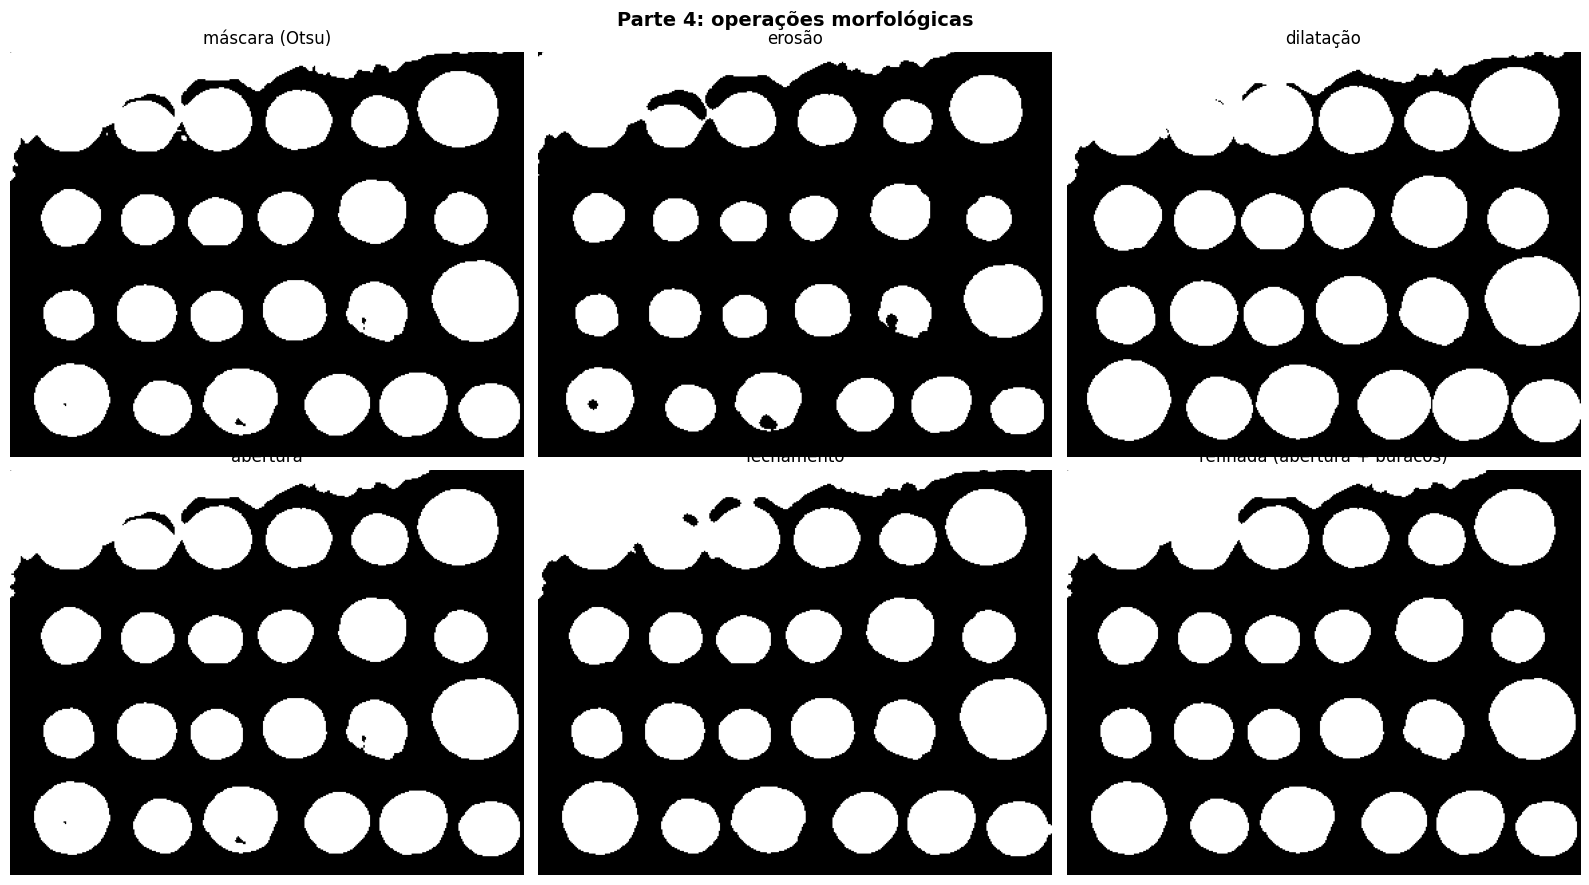

In [3]:
elem = morphology.disk(3)
erosao = morphology.erosion(mascara, elem)
dilatacao = morphology.dilation(mascara, elem)
abertura = morphology.opening(mascara, elem)
fechamento = morphology.closing(mascara, elem)
refinada = ndi.binary_fill_holes(morphology.opening(mascara, elem))

painel = [('máscara (Otsu)', mascara), ('erosão', erosao), ('dilatação', dilatacao),
          ('abertura', abertura), ('fechamento', fechamento),
          ('refinada (abertura + buracos)', refinada)]

fig, axes = plt.subplots(2, 3, figsize=(16, 9))
for ax, (titulo, m) in zip(axes.ravel(), painel):
    ax.imshow(m)
    ax.set_title(titulo)
    ax.axis('off')
plt.suptitle('Parte 4: operações morfológicas', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

**Que problema cada operação resolveu.** A abertura tirou os pontinhos claros soltos no fundo, que
eram sobra da limiarização, sem diminuir o tamanho das moedas. O preenchimento de buracos fechou as
falhas internas e deixou cada moeda como uma região cheia, o que importa para medir área e perímetro
direito mais na frente.

**O que mudou na estrutura dos objetos.** Dá para ver nos painéis: a erosão deixa as moedas menores
e chega a quebrar as mais finas; a dilatação engorda tudo e cola ainda mais as vizinhas; a abertura
mantém o tamanho e limpa o ruído; o fechamento tapa buracos, mas cria pontes entre moedas
encostadas. No fim, a máscara refinada ficou a mais limpa para continuar: fundo sem ruído e moedas
sólidas.

## 5. Identificação de objetos

Começo identificando os objetos por **componentes conectados** (`measure.label`) na máscara refinada
da etapa anterior: cada grupo de pixels grudados ganha um rótulo. Como já era de esperar, as moedas
que se tocam viram um componente só e a contagem fica abaixo das 24 reais.

Para separar as moedas encostadas, mudo a estratégia: em vez de olhar só a máscara binária, uso a
informação de borda. Calculo o gradiente da imagem com o filtro de **Sobel**, que realça a linha de
separação entre duas moedas coladas, e rodo um **watershed controlado por marcadores**, marcando os
pixels bem escuros como fundo e os bem claros como moeda. O watershed cresce a partir desses
marcadores até encontrar as bordas, e é isso que separa as peças que se encostam.

Moedas reais na imagem: 24
Componentes conectados (contagem direta): 22
Objetos pelo metodo baseado em bordas: 24


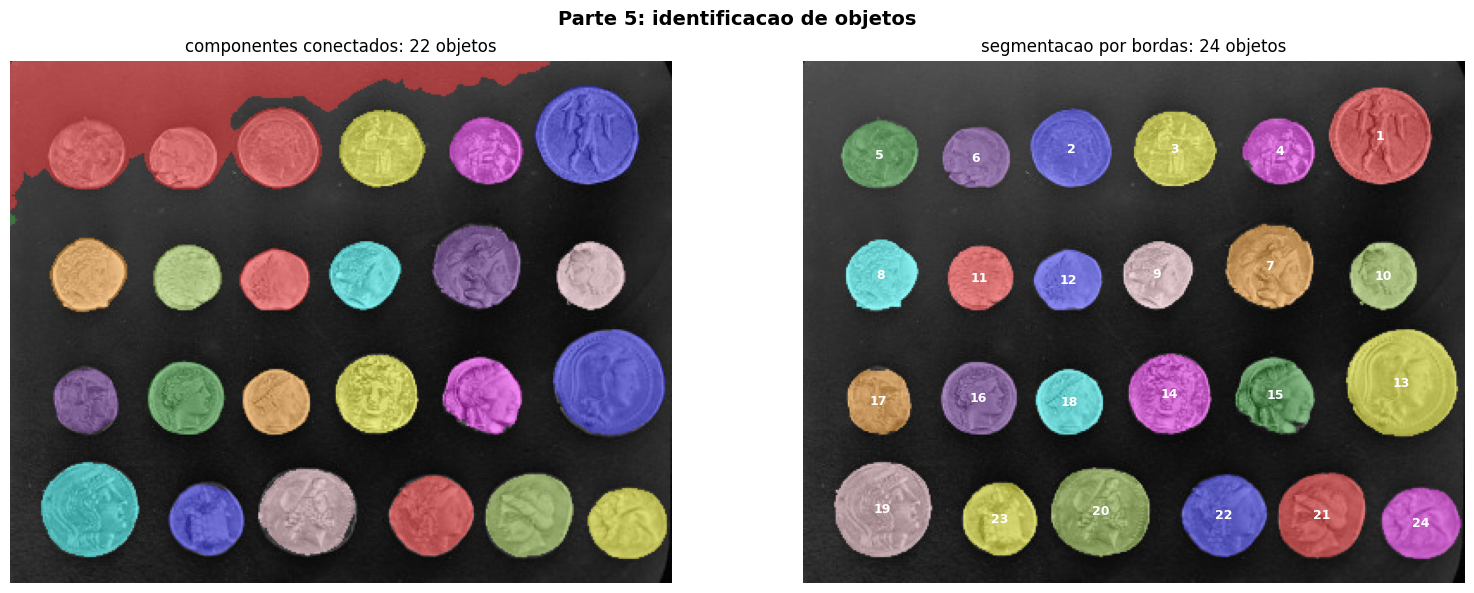

In [4]:
rotulos_cc = measure.label(refinada)
n_cc = len([p for p in measure.regionprops(rotulos_cc) if p.area >= 300])

elevacao = filters.sobel(img)
marcadores = np.zeros_like(img, dtype=int)
marcadores[img < 30] = 1
marcadores[img > 150] = 2
regioes = segmentation.watershed(elevacao, marcadores)
moedas = ndi.binary_fill_holes(regioes == 2)
moedas = morphology.remove_small_objects(moedas, min_size=200)
rotulos = measure.label(moedas)
n_obj = rotulos.max()

print('Moedas reais na imagem: 24')
print(f'Componentes conectados (contagem direta): {n_cc}')
print(f'Objetos pelo metodo baseado em bordas: {n_obj}')

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
axes[0].imshow(color.label2rgb(rotulos_cc, image=img, bg_label=0, alpha=0.4))
axes[0].set_title(f'componentes conectados: {n_cc} objetos')
axes[1].imshow(color.label2rgb(rotulos, image=img, bg_label=0, alpha=0.4))
for p in measure.regionprops(rotulos):
    y, x = p.centroid
    axes[1].text(x, y, str(p.label), color='white', fontsize=9,
                 ha='center', va='center', fontweight='bold')
axes[1].set_title(f'segmentacao por bordas: {n_obj} objetos')
for ax in axes:
    ax.axis('off')
plt.suptitle('Parte 5: identificacao de objetos', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

**Todos os objetos foram identificados certo?** Agora sim. A contagem direta por componentes
conectados fica em 22, abaixo das 24, porque junta num componente só as moedas que se tocam. Já o
método baseado em bordas chega às 24 moedas, separando até as encostadas da fileira de cima, e sem
deixar blobs gigantes nem fragmentos soltos (as áreas saem todas na mesma faixa, como dá para
conferir na tabela da próxima etapa).

**Possíveis causas de erro.** O erro dos componentes conectados vem do contato físico entre as
moedas: a máscara binária não tem como saber onde uma termina e a outra começa. O método por bordas
contorna isso porque enxerga o gradiente entre as peças. O que ainda pode atrapalhar esse segundo
método é a iluminação não uniforme, que muda o brilho do fundo e das moedas. Os limiares dos
marcadores (escuro abaixo de 30, claro acima de 150) foram escolhidos com folga para esta imagem,
mas precisariam de ajuste em fotos com luz bem diferente.

## 6. Extração de características

Para cada objeto do watershed, extraio um conjunto de características geométricas e de intensidade
com `measure.regionprops_table`. Além das três pedidas, incluí algumas medidas a mais que ajudam na
análise:

* **área**: número de pixels do objeto
* **perímetro**: comprimento do contorno
* **centroide**: posição do centro (x e y)
* **excentricidade**: o quanto a forma é alongada (0 = círculo perfeito)
* **intensidade média**: brilho médio da moeda
* **diâmetro equivalente**: diâmetro do círculo de mesma área
* **solidez**: razão entre a área e a do seu fecho convexo

In [5]:
tabela = measure.regionprops_table(
    rotulos, intensity_image=img,
    properties=['label', 'area', 'perimeter', 'centroid', 'eccentricity',
                'mean_intensity', 'equivalent_diameter_area', 'solidity'])

df = pd.DataFrame(tabela)
df.columns = ['objeto', 'área', 'perímetro', 'centro_y', 'centro_x', 'excentricidade',
              'intensidade_média', 'diâmetro_equiv', 'solidez']
df = df[['objeto', 'área', 'perímetro', 'centro_x', 'centro_y', 'excentricidade',
         'intensidade_média', 'diâmetro_equiv', 'solidez']].round(2)

print(df.to_string(index=False))

 objeto   área  perímetro  centro_x  centro_y  excentricidade  intensidade_média  diâmetro_equiv  solidez
      1 2604.0     188.75    334.66     43.54            0.33             156.81           57.58     0.98
      2 1653.0     150.37    155.26     50.77            0.29             169.37           45.88     0.98
      3 1622.0     148.71    215.24     51.10            0.38             157.61           45.44     0.98
      4 1225.0     131.05    276.13     52.39            0.39             154.20           39.49     0.97
      5 1355.0     137.05     44.18     54.39            0.51             167.82           41.54     0.97
      6 1103.0     123.15    100.18     56.12            0.43             184.32           37.48     0.97
      7 1920.0     163.20    270.58    118.81            0.34             158.61           49.44     0.97
      8 1298.0     135.05     44.74    124.31            0.35             190.66           40.65     0.97
      9 1209.0     127.64    205.26    123.73 

## 7. Análise dos resultados

O gráfico abaixo cruza área e intensidade média para ver o quanto essas duas características ajudam a
separar os objetos.

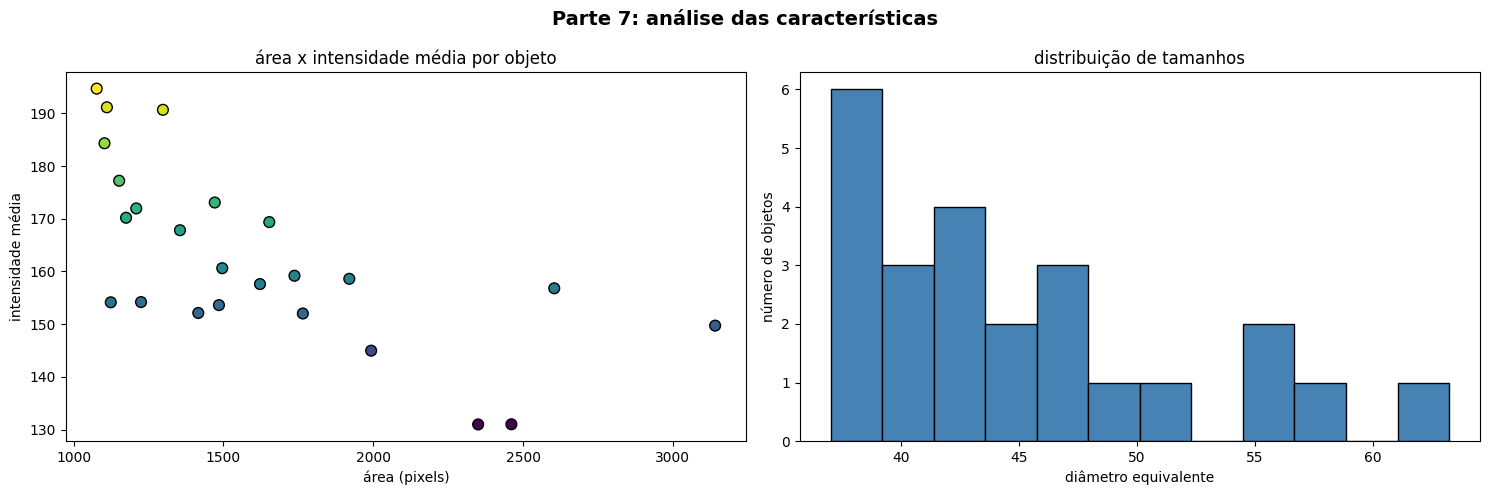

Resumo estatístico:
          área  perímetro  excentricidade  intensidade_média  diâmetro_equiv  solidez
count    24.00      24.00           24.00              24.00           24.00    24.00
mean   1622.62     147.82            0.34             162.76           44.91     0.98
std     546.42      23.79            0.08              17.00            7.17     0.01
min    1077.00     121.15            0.20             130.99           37.03     0.95
25%    1200.50     127.35            0.26             153.25           39.09     0.97
50%    1478.00     140.88            0.34             158.90           43.38     0.98
75%    1803.75     157.82            0.42             172.24           47.92     0.98
max    3141.00     207.82            0.51             194.68           63.24     0.98


In [6]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5))
axes[0].scatter(df['área'], df['intensidade_média'], c=df['intensidade_média'],
                cmap='viridis', s=60, edgecolor='k')
axes[0].set_xlabel('área (pixels)')
axes[0].set_ylabel('intensidade média')
axes[0].set_title('área x intensidade média por objeto')
axes[1].hist(df['diâmetro_equiv'], bins=12, color='steelblue', edgecolor='k')
axes[1].set_xlabel('diâmetro equivalente')
axes[1].set_ylabel('número de objetos')
axes[1].set_title('distribuição de tamanhos')
plt.suptitle('Parte 7: análise das características', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

print('Resumo estatístico:')
print(df[['área', 'perímetro', 'excentricidade', 'intensidade_média',
          'diâmetro_equiv', 'solidez']].describe().round(2).to_string())

**As características distinguem os objetos?** Sim, principalmente as de tamanho e brilho. A área e o
diâmetro equivalente agrupam as moedas por tamanho (a distribuição mostra mais de um grupo, o que
bate com moedas de valores diferentes), e a intensidade média separa as mais claras das mais
escuras. Com as duas juntas, cada moeda cai numa posição quase única no gráfico.

**Quais são mais informativas.** O diâmetro equivalente e a área são os melhores para diferenciar o
tipo de moeda, por serem medidas de tamanho estáveis. A intensidade média ajuda com moedas de
material ou conservação diferentes. A excentricidade e a solidez quase não variam (todas as moedas
são redondas e cheias), então servem pouco para distinguir uma da outra, mas funcionam como
conferência da segmentação: um valor fora do padrão denunciaria um objeto mal separado. Como as 24
saíram redondas e com solidez perto de 1, dá para confiar que a separação ficou boa.

**Como melhorar o pipeline.** O ponto mais frágil é a sensibilidade à iluminação. Daria para trocar
os limiares fixos dos marcadores por limiares adaptativos, ou corrigir o fundo antes de segmentar,
deixando o método robusto a fotos com luz diferente. Com uma referência de escala, dava para
converter área e diâmetro de pixels para milímetros. E, como as características já estão em tabela,
daria para treinar um classificador simples que diga o valor de cada moeda a partir do tamanho e do
brilho.

## 8. Conclusão

O pipeline funcionou de ponta a ponta e mostrou como cada etapa depende da anterior. O Otsu separou
as moedas do fundo, a morfologia limpou a máscara e fechou o miolo das peças, e a identificação
chegou às 24 moedas. O aprendizado principal está aí: a contagem direta por componentes conectados
parava em 22, porque juntava as moedas encostadas, e foi preciso trazer a informação de borda (Sobel
com watershed por marcadores) para separar essas peças e acertar o total. A extração de
características fechou o trabalho com medidas que diferenciam as moedas por tamanho e brilho.

No fim, fica a ideia de sempre nesse tipo de tarefa: a segmentação manda no resto do pipeline. Uma
máscara binária simples já resolve a separação entre objeto e fundo, mas separar objetos que se
tocam exige um passo a mais, e a escolha de cada método precisa olhar para a imagem e para o que se
quer medir.